# Data Analysis

# Clinic 3: Classification with missing values & inbalanced data

## DELIVERABLES (DEADLINE 06/Mar late night, wildcards possible)

Instructions for the deliverable: 

* Make sure that you include a proper amount/mix of comments, results and code.

* In the end, make sure that all cells are executed properly and everything you need to show is in your (execucted) notebook.

* You are asked to deliver **only your executed notebook file, .ipnyb** and nothing else. Enjoy!

* The second part of the assignment is purposefully left open-ended.

## Score breakdown

Question | Points
--- | ---
[Question 1](#q1) | 3
[Question 2](#q2) | 6
[Question 3](#q3) | 3
[Question 4](#q4) | 4
[Question 5](#q5) | 4
[Question 6](#q6) | 6
[Question 7](#q7) | 6
[Question 8](#q8) | 4
[Question 9](#q9) | 6
[Question 10](#q10)| 18
Total | 60

This score will be scaled down to 1 and that will be your final clinic score.

## Learning Goals

By the end of this clinic, you should be able to:

- Build classification models for credit default prediction
- Quantify and handle class imbalance
- Understand why accuracy fails in imbalanced settings
- Compare:
  - Accuracy
  - ROC-AUC
  - Precision-Recall AUC
  - Confusion matrices
- Use:
  - Cross-validation
  - Regularization
  - Class weighting
  - Threshold tuning

# 0. The dataset

### What is LendingClub?

LendingClub is a peer-to-peer lending platform that connects borrowers with investors. Instead of borrowing from a traditional bank, individuals apply for loans through the platform. Investors then fund these loans and receive returns if borrowers repay successfully.

The dataset used in this clinic contains historical loan data, including:

- Borrower characteristics
- Loan characteristics
- Credit risk indicators
- Loan repayment outcomes

Our goal is to predict whether a loan will **default**.

---

### What is the Prediction Task?

We focus on a binary classification problem:

- `default = 1` → Loan was **Charged Off** (borrower failed to repay)
- `default = 0` → Loan was **Fully Paid**

This is a classic **credit risk modeling** problem.

It is also a naturally **imbalanced dataset**, since most borrowers repay their loans.

### Structure of the Dataset

The dataset contains several categories of variables.

---

### 1️⃣ Borrower Employment & Income Information

- `emp_title` – Job title of the borrower  
- `emp_length` – Length of employment (in years)
- `annual_income` – Borrower’s reported annual income (in USD)
- `verified_income` – Whether income was verified (yes/no)
- `annual_income_joint` – Joint annual income (if co-borrower e.g. for couples)  
- `verification_income_joint` – Whether joint income was verified  
---

### 2️⃣ Housing & Application Information

- `state` – U.S. state of residence
- `homeownership` – three options: RENT / OWN / MORTGAGE  
- `application_type` – Individual or joint application  
- `loan_purpose` – Purpose of the loan (e.g., debt consolidation, credit card, car)  
---

### 3️⃣ Debt & Financial Burden Measures

- `debt_to_income` – Debt-to-income ratio
- `debt_to_income_joint` – Joint DTI (if applicable)  
- `installment` – Monthly loan payment (in USD)
- `loan_amount` – Total loan amount requested (in USD)
- `term` – Loan duration (in months)
- `interest_rate` – Interest rate assigned to the loan (in %)
---

### 4️⃣ Credit History Indicators

- `earliest_credit_line` – Year of first credit line  
- `delinq_2y` – Delinquencies in past 2 years (*delinquency* means failure to fulfill a financial obligation)
- `inquiries_last_12m` – Credit inquiries in last 12 months  
- `months_since_last_delinq` - months since ast delinquency 
- `months_since_90d_late` - a 90-day delinquency is a serious milestone in credit reporting
- `num_accounts_30d_past_due` - number of accounts that are 30 days past due
- `num_accounts_120d_past_due` - number of accounts that are 120 days past due
- `current_accounts_delinq` - number of accounts in delinquency
- `num_historical_failed_to_pay` - times that failed a payment in the past
- `public_record_bankrupt` - whether exists a public record for bankruptcy
- `tax_liens` - yes/no: a lien is a legal claim placed by some authority (usually public) against a person’s property 
---

### 5️⃣ Credit Utilization & Account Structure

- `total_credit_lines` - # of credit lines
- `open_credit_lines` - # of open credit ines
- `total_credit_limit` - credit limit (in USD)
- `total_credit_utilized` - credit used (in USD)
- `account_never_delinq_percent` - %
- `num_satisfactory_accounts` - # of accounts
- `num_open_cc_accounts` - # of accounts
- `num_cc_carrying_balance` - # credit cards carrying balance
- `num_active_debit_accounts` - # of accounts
- `total_debit_limit` - debit limit (in USD)
- `num_mort_accounts` - # of mortgage accounts
- `accounts_opened_24m` - # of accounts opened in the last 24 months
---

### 6️⃣ LendingClub Risk Grades

- `grade` – Risk category (A–G), internal assessment by LendingClub
- `sub_grade` – More granular risk classification, also by LendingClub
---

### 7️⃣ Loan Outcome Variables

- `balance` – Remaining balance  (in USD)
- `paid_total` – Total amount paid (in USD)
- `paid_principal` – Principal repaid (in USD)
- `paid_interest` – Interest paid (in USD)
- `paid_late_fees` – Late fees paid (in USD)
- `issue_month` – month/year of issue
- `initial_listing_status` – whole or functional  
- `disbursement_method` – How funds were disbursed 

- `default` – Final loan outcome (0 or 1) This is our prediction variable.

In [124]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.api import OLS
#from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LogisticRegressionCV
from sklearn.utils import resample
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
%matplotlib inline
import seaborn as sns
sns.set(context='paper')

In [125]:
# Load the loans dataset
loans = pd.read_csv('loans_full_schemaa.csv')
pd.set_option('display.max_columns', None)


# Display basic information about the dataset
print(f"Dataset shape: {loans.shape}")
loans.head(12)

Dataset shape: (10000, 55)


,emp_title,emp_length,state,homeownership,annual_income,verified_income,debt_to_income,annual_income_joint,verification_income_joint,debt_to_income_joint,delinq_2y,months_since_last_delinq,earliest_credit_line,inquiries_last_12m,total_credit_lines,open_credit_lines,total_credit_limit,total_credit_utilized,num_collections_last_12m,num_historical_failed_to_pay,months_since_90d_late,current_accounts_delinq,total_collection_amount_ever,current_installment_accounts,accounts_opened_24m,months_since_last_credit_inquiry,num_satisfactory_accounts,num_accounts_120d_past_due,num_accounts_30d_past_due,num_active_debit_accounts,total_debit_limit,num_total_cc_accounts,num_open_cc_accounts,num_cc_carrying_balance,num_mort_accounts,account_never_delinq_percent,tax_liens,public_record_bankrupt,loan_purpose,application_type,loan_amount,term,interest_rate,installment,grade,sub_grade,issue_month,initial_listing_status,disbursement_method,balance,paid_total,paid_principal,paid_interest,paid_late_fees,default
0,global config engineer,3.0,NJ,MORTGAGE,90000.0,Verified,18.01,NaN,NaN,NaN,0,38.0,2001,6,28,10,70795,38767,0,0,38.0,0,1250,2,5,5.0,10,0.0,0,2,11100,14,8,6,1,92.9,0,0,moving,individual,28000,60,14.07,652.53,C,C3,Mar/18,whole,Cash,27015.86,1999.33,984.14,1015.19,0.0,0
1,warehouse office clerk,10.0,HI,RENT,40000.0,Not Verified,5.04,NaN,NaN,NaN,0,NaN,1996,1,30,14,28800,4321,0,1,NaN,0,0,0,11,8.0,14,0.0,0,3,16500,24,14,4,0,100.0,0,1,debt_consolidation,individual,5000,36,12.61,167.54,C,C1,Feb/18,whole,Cash,4651.37,499.12,348.63,150.49,0.0,0
2,assembly,3.0,WI,RENT,40000.0,Source Verified,21.15,NaN,NaN,NaN,0,28.0,2006,4,31,10,24193,16000,0,0,28.0,0,432,1,13,7.0,10,0.0,0,3,4300,14,8,6,0,93.5,0,0,other,individual,2000,36,17.09,71.40,D,D1,Feb/18,fractional,Cash,1824.63,281.80,175.37,106.43,0.0,0
3,customer service,1.0,PA,RENT,30000.0,Not Verified,10.16,NaN,NaN,NaN,0,NaN,2007,0,4,4,25400,4997,0,1,NaN,0,0,1,1,15.0,4,0.0,0,2,19400,3,3,2,0,100.0,1,0,debt_consolidation,individual,21600,36,6.72,664.19,A,A3,Jan/18,whole,Cash,18853.26,3312.89,2746.74,566.15,0.0,0
4,security supervisor,10.0,CA,RENT,35000.0,Verified,57.96,57000.0,Verified,37.66,0,NaN,2008,7,22,16,69839,52722,0,0,NaN,0,0,1,6,4.0,16,0.0,0,10,32700,20,15,13,0,100.0,0,0,credit_card,joint,23000,36,14.07,786.87,C,C3,Mar/18,whole,Cash,21430.15,2324.65,1569.85,754.80,0.0,1
5,NaN,NaN,KY,OWN,34000.0,Not Verified,6.46,NaN,NaN,NaN,1,3.0,1990,6,32,12,42100,3898,0,0,60.0,0,0,0,2,5.0,12,0.0,0,1,27200,27,12,5,3,78.1,0,0,other,individual,5000,36,6.72,153.75,A,A3,Jan/18,whole,Cash,4256.71,873.13,743.29,129.84,0.0,0
6,hr,10.0,MI,MORTGAGE,35000.0,Source Verified,23.66,155000.0,Not Verified,13.12,0,NaN,2004,1,12,10,291852,18916,0,0,NaN,0,0,2,1,9.0,10,0.0,0,3,9100,8,7,6,2,100.0,0,0,credit_card,joint,24000,60,13.59,553.35,C,C2,Jan/18,whole,Cash,22560.00,2730.51,1440.00,1290.51,0.0,0
7,police,10.0,AZ,MORTGAGE,110000.0,Source Verified,16.19,NaN,NaN,NaN,1,19.0,2005,1,30,15,342336,60805,0,0,71.0,0,0,2,4,7.0,15,NaN,0,5,22250,16,12,10,7,93.0,0,0,debt_consolidation,individual,20000,60,11.99,444.79,B,B5,Jan/18,whole,Cash,19005.39,1765.84,994.61,771.23,0.0,0
8,parts,10.0,NV,MORTGAGE,65000.0,Source Verified,36.48,NaN,NaN,NaN,1,18.0,1998,3,35,21,283190,69561,0,0,18.0,0,0,6,10,4.0,21,0.0,0,11,36700,19,14,14,2,97.1,0,0,home_improvement,individual,20000,36,13.59,679.58,C,C2,Feb/18,whole,Cash,18156.66,2703.22,1843.34,859.88,0.0,0
9,4th person,3.0,IL,RENT,30000.0,Not Verified,18.91,NaN,NaN,NaN,0,NaN,2001,0,9,6,33114,17768,0,0,NaN,0,0,1,5,17.0,6,0.0,0,3,14700,7,5,3,0,100.0,0,0,credit_card,individual,6400,36,6.71,196.77,A,A3,Mar/18,fractional,Cash,6077.13,391.15,322.87,68.28,0.0,0


In [126]:
# Display column names and data types
loans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 55 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   emp_title                         9167 non-null   object 
 1   emp_length                        9183 non-null   float64
 2   state                             10000 non-null  object 
 3   homeownership                     10000 non-null  object 
 4   annual_income                     10000 non-null  float64
 5   verified_income                   10000 non-null  object 
 6   debt_to_income                    9976 non-null   float64
 7   annual_income_joint               1495 non-null   float64
 8   verification_income_joint         1455 non-null   object 
 9   debt_to_income_joint              1495 non-null   float64
 10  delinq_2y                         10000 non-null  int64  
 11  months_since_last_delinq          4342 non-null   float64
 12  earli

## Part 1: Pre-processing

Before building any model, remove variables that would not have been known at the time the loan *was issued*. Using post-outcome information is called **data leakage** (which we covered in class) and leads to unrealistically high performance.

### Question 1: Data leakage

1. Which variables in this dataset must be excluded due to data leakage?
2. Why are they invalid predictors?
3. What would happen to model performance if you kept them?
4. Write code that would remove the variables from the dataframe.

Hint: Look for variables that describe repayment amounts, balances, late fees, or the final loan outcome.


**Answer:**
1. Firstly we exclude most features from section 7, namely **balance, paid_total, paid_principal, paid_interest, paid_late_fees** — all of these reflect what happened during repayment, and we would not have access to this information during typical infernece. 
2. We also exclude **grade** and **sub_grade** as they are likely features craeted by a different model and we want our model to be acting independent and to base its predicitons on the raw features.
3. Some of the features from section 4 like **current_accounts_delinq** could be potentially leaking if they were updated during the repayment process, however if they were set at the start of the loan and kept untouched they are fine to use. We will keep them for now.
4. Lastly we exclude **default** because this is the variable we want to predict. (Though we are not removing it from the dataset in the code below because we still need it to train our model.)

In [127]:
# Remove variables potentially causing data leakage
cols_to_drop = ['balance', 'paid_total', 'paid_principal', 'paid_interest', 'paid_late_fees',
                'grade', 'sub_grade']

loans = loans.drop(columns=cols_to_drop)

### Question 2: Analyze Missing Values

Now that we got rid of the "leakage" variables, it's important to understand the extent and pattern of missing data in the dataset.

1. Calculate the percentage of missing values for each column in the dataset.
2. Identify the top 10 columns with the highest percentage of missing values.
3. Create a proper visualization (bar plot or other) showing missing value patterns. We give bonus points if you come up with a suitable visualization going beyond the standard (which is still perfcetly fine)

Afterwards, discuss:

4. Which variables have substantial missingness (>20%)?

5. Are there any patterns in the missingness that could be informative (refer to the MAR, MNAR, MCAR concepts from week 1)?

6. How might you handle these missing values in your modeling pipeline? Implement some function to handle it on your dataframe.

7. Could the missingness itself be informative? (e.g., missing employment length might indicate self-employment)

In [128]:
# 1. Calculate missing value counts and percentages
missing_counts = loans.isnull().sum()
missing_percentages = loans.isnull().mean() * 100
print(f"\nTotal number of rows: {len(loans)}")
print(f"Total number of columns: {len(loans.columns)}")
print(f"\nColumns with missing values: {(missing_counts > 0).sum()}")
print(f"Columns with NO missing values: {(missing_counts == 0).sum()}")


Total number of rows: 10000
Total number of columns: 48

Columns with missing values: 10
Columns with NO missing values: 38


In [129]:
# 2. Identify the top 10 columns with the highest percentage of missing values
top_10_missing = missing_percentages[missing_percentages > 0].sort_values(ascending=False).head(10)
print("Top 10 columns by missing value %:")
print(top_10_missing.round(2).to_string())

Top 10 columns by missing value %:
verification_income_joint           85.45
annual_income_joint                 85.05
debt_to_income_joint                85.05
months_since_90d_late               77.15
months_since_last_delinq            56.58
months_since_last_credit_inquiry    12.71
emp_title                            8.33
emp_length                           8.17
num_accounts_120d_past_due           3.18
debt_to_income                       0.24


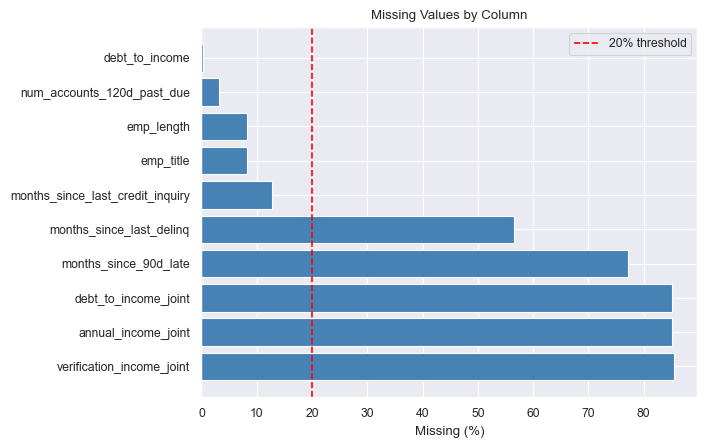

In [130]:
# 3. Create visualization showing missing value patterns
missing_any = missing_percentages[missing_percentages > 0].sort_values(ascending=False)

plt.barh(missing_any.index, missing_any.values, color='steelblue')
plt.axvline(x=20, color='red', linestyle='--', label='20% threshold')
plt.xlabel('Missing (%)')
plt.title('Missing Values by Column')
plt.legend()

plt.show()

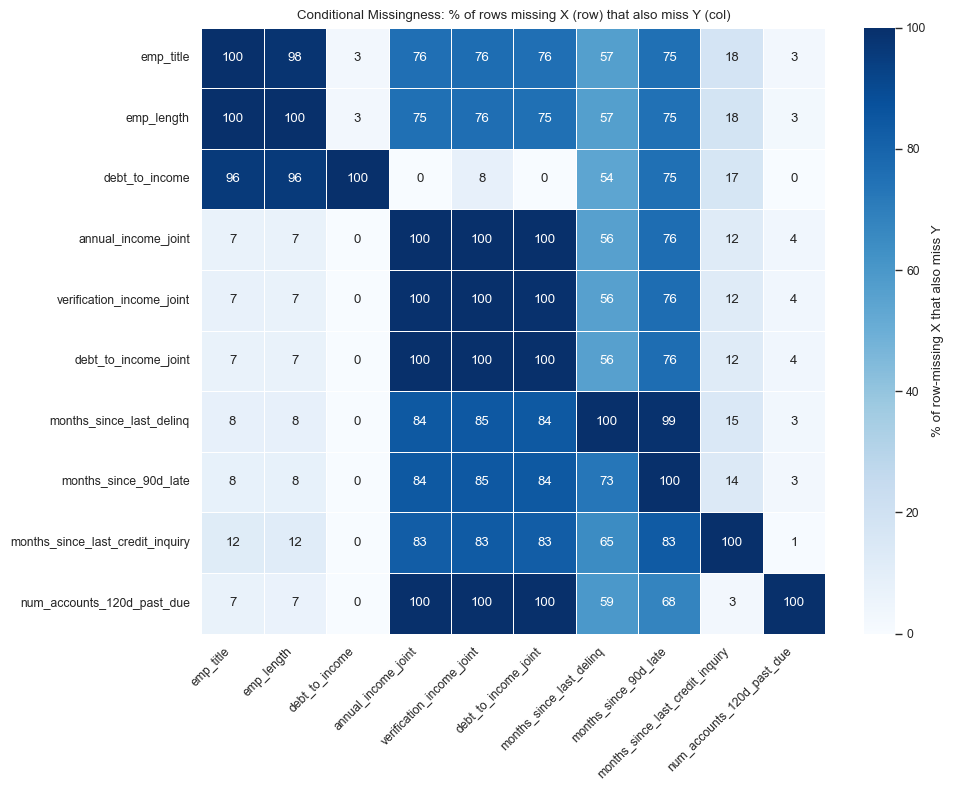

In [131]:
# Bonus graph
# Conditional missingness matrix: % of rows missing X that also miss Y
# cell (i, j) = P(j missing | i missing)
cols_with_missing = missing_percentages[missing_percentages > 0].index.tolist()

cond_missing = pd.DataFrame(index=cols_with_missing, columns=cols_with_missing, dtype=float)

for col_i in cols_with_missing:
    mask_i = loans[col_i].isnull()
    for col_j in cols_with_missing:
        if mask_i.sum() == 0:
            cond_missing.loc[col_i, col_j] = 0.0
        else:
            cond_missing.loc[col_i, col_j] = (mask_i & loans[col_j].isnull()).sum() / mask_i.sum() * 100

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cond_missing.astype(float), annot=True, fmt='.0f', cmap='Blues',
            linewidths=0.5, ax=ax, cbar_kws={'label': '% of row-missing X that also miss Y'})
ax.set_title('Conditional Missingness: % of rows missing X (row) that also miss Y (col)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


**Answer:**

4. Features with missing values >20% are **months_since_last_delinq, months_since_90d_late, debt_to_income_joint, annual_income_joint** and **verification_income_joint**

5. **debt_to_income** and **num_accounts_past_120d_late** seem to be missing completely at random MCAR. All of the **joint** features are always missing together which probably means that they are missing not at random MAR and are likely explained by the fact that the loan was taken by an individual. However, values like **months_since_last_delinq, months_since_90d_late** and **months_since_last_credit_inquiry** may be missing not at random MNAR and mean that the subject has never been deliquent, late or taken a credit. 

6. 
    - For **debt_to_income** and **num_accounts_past_120d_late** we can simply impute mediaan as it is MCAR. 
    
    - For all **months_since_...** we assume that missing values mean that the certain event has never happend hence we put 999 in the missing columns to emphasize that fact and make it understandable for the model. 

    - For all **..._joint** variables we simply drop their columns as 85% of rows are missing the values there, and imputing them would be meaningless as the fact that they are missing means the application is individual so these columns should be Null anyways. 

    - We also drop **emp_title** as it's a non-numerical feature that will be impossible for us to use effectively. 

    - Missing **emp_length** may mean self-employment or un-employment - we don't know which, but to make it understandable for the model we change the missing values to -1 to highlight this special case.

7. Like mentioned above some missing values may be informative like missing **emp_length** may mean self-employment or un-employment or **months_since_...** may mean that certain event has never happened before. Hence the missingness itself may be informative.


In [132]:
#here incude code to handle the missing values
def handle_missing_values(df):
    df = df.copy()

    # Median imputation for MCAR columns
    for col in ['debt_to_income', 'num_accounts_120d_past_due']:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].median())

    # months_since_... to 999 
    months_since_cols = [col for col in df.columns if col.startswith('months_since_')]
    for col in months_since_cols:
        df[col] = df[col].fillna(999)

    # Drop all joint variables
    joint_cols = [col for col in df.columns if col.endswith('_joint')]
    df = df.drop(columns=joint_cols)

    # Drop emp_title
    if 'emp_title' in df.columns:
        df = df.drop(columns=['emp_title'])

    # emp_length to -1
    if 'emp_length' in df.columns:
        df['emp_length'] = df['emp_length'].fillna(-1)

    return df

In [133]:
loans = handle_missing_values(loans)

### Question 3: Quantify the Imbalance

We now focus on the binary variable `default`, which is the one we want to predict.

1. Compute the percentage of:
   - Defaulted loans 
   - Fully paid loans 
2. Which class is the majority?
3. Which class is the minority?
4. What would be the accuracy of a classifier that predicts all loans as Fully Paid?
5. Make an appropriate plot to show the class imbalance

In [134]:
# 1. Compute the percentage of defaulted and fully paid loans
default_rate = loans['default'].mean() * 100
paid_rate = 100 - default_rate
print(f"Fully Paid:    {paid_rate:.2f}%")
print(f"Defaulted:     {default_rate:.2f}%")

# 2 & 3. Identify majority and minority classes
print(f"\nMajority class: {'Fully Paid (0)' if paid_rate > default_rate else 'Defaulted (1)'}")
print(f"Minority class: {'Defaulted (1)' if paid_rate > default_rate else 'Fully Paid (0)'}")

# Calculate imbalance ratio
imbalance_ratio = paid_rate / default_rate
print(f"\nImbalance ratio: {imbalance_ratio:.1f}:1  (paid:default)")

Fully Paid:    98.00%
Defaulted:     2.00%

Majority class: Fully Paid (0)
Minority class: Defaulted (1)

Imbalance ratio: 49.0:1  (paid:default)


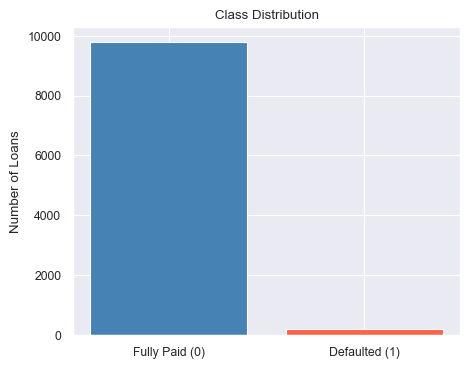

In [135]:
# Visualization: Class Distribution
counts = loans['default'].value_counts().sort_index()
labels = ['Fully Paid (0)', 'Defaulted (1)']

plt.figure(figsize=(5, 4))
plt.bar(labels, counts.values, color=['steelblue', 'tomato'])
plt.ylabel('Number of Loans')
plt.title('Class Distribution')
plt.show()


**Answer:** the accurancy of a model that simply classifies all loans as Fully Paid would be 98%

### Question 4: Why Accuracy Fails

1. Why is accuracy not an appropriate metric in this dataset?
2. In credit lending, we assume that the cost of missing a default (i.e. lose an entire loan because a bad decision to hand out the loan was made) is approx. and on average 10,000 USD and the cost of rejecting a good borrower (i.e. the lost profit for rejecting a loan that would pay in ful) is 500 USD. Which is more costly:

   - A False Negative (missed defaulter)?
   - A False Positive (rejected good borrower)?
   
   Support your conclusions with calculations and plots.
   
3. Which metric would better reflect business risk?

**Answer:** The accuracy is not a good metric bc it fails to show that 100% of the minority class will be wrongfully predicted.

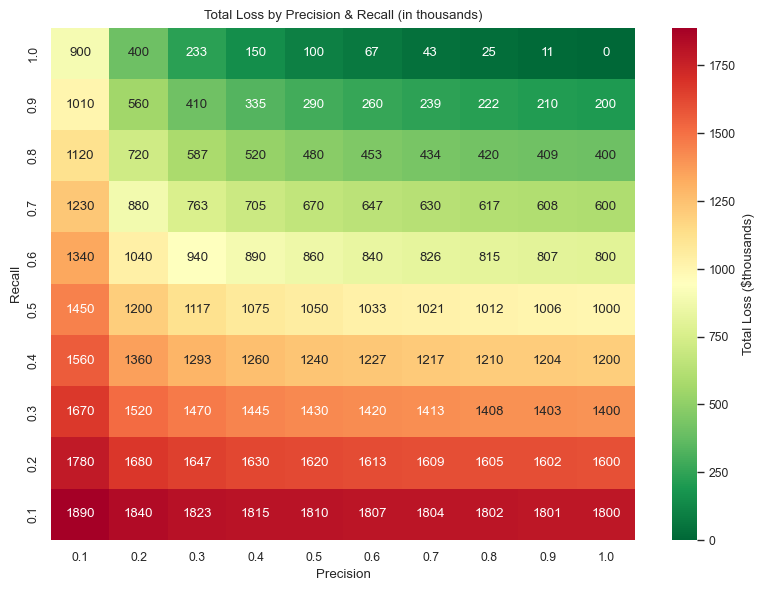

In [136]:
precision_vals = np.arange(0.1, 1.1, 0.1)
recall_vals = np.arange(0.1, 1.1, 0.1)

n_total = len(loans)
default_rate = loans['default'].mean()
n_defaults = default_rate * n_total

loss_matrix = np.zeros((len(recall_vals), len(precision_vals)))

for i, recall in enumerate(recall_vals):
    for j, precision in enumerate(precision_vals):
        tp = recall * n_defaults
        fn = (1 - recall) * n_defaults
        fp = tp * (1 - precision) / precision
        loss_matrix[i, j] = (fn * 10_000 + fp * 500) / 1_000  # in $thousands

# Flip rows so recall=1 is at the top
loss_matrix = np.flipud(loss_matrix)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    loss_matrix,
    xticklabels=np.round(precision_vals, 1),
    yticklabels=np.round(recall_vals[::-1], 1),
    annot=True, fmt='.0f',
    cmap='RdYlGn_r',
    ax=ax,
    cbar_kws={'label': 'Total Loss ($thousands)'}
)
ax.set_xlabel('Precision')
ax.set_ylabel('Recall')
ax.set_title('Total Loss by Precision & Recall (in thousands)')
plt.tight_layout()
plt.show()


**Answer:** By their absolute value FN is more expensive than FP (10000 > 500). This is why, as seen on the heatmap above, focusing on maximising the recall is a good strategy. Nonetheless, because the negatives are the majority class completely ignoring them will still bring big losses. That is why the best strategy is a weighted F1 score with bigger weight on recall.

### Question 5: Identify Valid Features

1. We are now considering the rest of the features (after removing leakage variables).

   Identify which features are:
   - Numerical?
   - Categorical?
   - Ordinal?

2. Which categorical variables need encoding?

3. Are there any variabes with high cardinality (i.e. high number of categories) that you woud consider removing?

In [137]:
# Drop high cardinality and process-related columns
loans = loans.drop(columns=['state', 'initial_listing_status', 'disbursement_method'])

# Recode loan_purpose into binary: financial vs other
financial_purposes = {'debt_consolidation', 'credit_card'}
loans['loan_purpose'] = loans['loan_purpose'].apply(
    lambda x: 'financial' if x in financial_purposes else 'other'
)

# issue_month looks like "Mar/18" so we parse into numeric year and month
loans['issue_year']  = pd.to_datetime(loans['issue_month'], format='%b/%y').dt.year
loans['issue_month_num'] = pd.to_datetime(loans['issue_month'], format='%b/%y').dt.month
loans = loans.drop(columns=['issue_month'])



In [138]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

# assuming verified_income has an order
ordinal_features = ['verified_income']
ordinal_categories = [['Not Verified', 'Source Verified', 'Verified']]

# nominal categoricals (no natural order)
nominal_features = ['homeownership', 'application_type', 'loan_purpose']

preprocessor = ColumnTransformer(transformers=[
    ('ordinal', OrdinalEncoder(categories=ordinal_categories), ordinal_features),
    ('nominal', OneHotEncoder(drop=None, sparse_output=False), nominal_features)
], remainder='passthrough', verbose_feature_names_out=False).set_output(transform='pandas')

loans = preprocessor.fit_transform(loans)

Question 1:

- **Ordinal features:** grade, sub_grade (although we already deleted both) and possibly verified_income if we assume that verified is more trustworthy than source_verified

- **Categorical features:** state, homeownership, loan_purpose, application_type, initial_listing_status, disbursement_method, term

- **Numerical features:** everything else (date will be numerical after we change the way it is saved)

Question 3:
- We decided to remove state (and emp_title earlier) due to too high cardinality. 
- We decided to also ignore initial_listing_status and disbursement_method as they are related to the company process of loaning and not the user itself. 
- We changed loan_purpose categories into just 2 reasons (financial or other) to decrease the cardinality. 

Question 2: Apart from term, all the other cardinal features required encoding.



## Part 2: Fit a logistic model ignoring missing values

Now by this point, we assume that you have dealt with missing values, possible data leakage and have done some first pre-processing decisions. Feel free to continue the exploration here, but keep in ind that Questions 6-8 are still informative (we don't care about performance yet). You will explore an open model in Question 10.

### Question 6: Logistic Regression (Baseline)

1. Fit a logistic regression model.
2. Report:
   - Accuracy
   - Confusion matrix
   - ROC-AUC
3. How many defaults does the model correctly detect?
4. How many defaults does it miss?

If you ignore the missingness `sklearn` might crash (`ValueError: Input contains NaN, infinity or a value too large for dtype('float64')`.) So you can also consider not using that variable in the model

In [139]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, roc_auc_score, 
                              roc_curve, classification_report)
from sklearn.preprocessing import LabelEncoder

In [140]:
# Your code here: 
########################
########################

# make sure to remove leakage variables (if not done already)


# make sure to remove other variables you identified before

# Get feature columns
feature_cols = [col for col in loans.columns if col not in exclude_vars]

print(f"\nFeature Selection:")
print(f"  Total columns in dataset: {len(loans.columns)}")
print(f"  Excluded columns: {len(exclude_vars)}")
print(f"  Features for modeling: {len(feature_cols)}")

NameError: name 'exclude_vars' is not defined

In [ ]:
# Step 2: Handle missing values - simple approach for baseline
# if you haven't done it before

In [ ]:
# Step 3: (possibly) numerical and categorical features

X = loans[feature_cols].copy()
y = loans['default'].copy()

numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f"\n  Numerical features: {len(numerical_cols)}")
print(f"  Categorical features: {len(categorical_cols)}")

In [ ]:
# Step 4: Train-test split

# Here we incorporate a different train/test split due to the high-inbalance. 
# We do stratisfy but we also as the split method to have at least 50 data points or 30%.
# That is for the case that we have very few data points (not appicable here)

n_defaults = y.sum()
min_test_defaults = max(int(n_defaults * 0.3), 25)  # At least 50 or 30%

print(f"Total defaults in dataset: {n_defaults}")
print(f"Target defaults in test set: {min_test_defaults}")

# If dataset too small, use larger test set
if n_defaults < 100:
    test_size = 0.4  # Use 40% for test if very few defaults
    print(f"⚠ Warning: Only {n_defaults} defaults total - using test_size={test_size}")
else:
    test_size = 0.3

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=test_size,
    random_state=1983,
    stratify=y
)

print(f"\nTrain-Test Split:")
print(f"  Training set: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Test set: {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"  Train default rate: {y_train.mean()*100:.2f}%")
print(f"  Test default rate: {y_test.mean()*100:.2f}%")

In [ ]:
# Step 5: Fit Logistic Regression

log_reg = LogisticRegression(max_iter=1000, random_state=1983)
log_reg.fit(X_train, y_train)

## Reminder: The Confusion Matrix & Some Useful Functions

- the samples that are +ive and the classifier predicts as +ive are called True Positives (TP)
- the samples that are -ive and the classifier predicts (wrongly) as +ive are called False Positives (FP)
- the samples that are -ive and the classifier predicts as -ive are called True Negatives (TN)
- the samples that are +ive and the classifier predicts as -ive are called False Negatives (FN)

A classifier produces a confusion matrix which looks like this:

![confusionmatrix](./confusionmatrix_360.png)


IMPORTANT NOTE: In `sklearn`, to obtain the confusion matrix in the form above, always have the observed `y` first, i.e.: use as `confusion_matrix(y_true, y_pred)`



In [ ]:
# Step 6: Make predictions and evaluate
y_pred = log_reg.predict(X_test)
y_pred_proba = log_reg.predict_proba(X_test)[:, 1]

# 2a. Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\n1. ACCURACY: {accuracy*100:.2f}%")

# Compare to naive baseline
naive_accuracy = (y_test == 0).mean()
print(f"   Naive baseline (always predict 0): {naive_accuracy*100:.2f}%")
print(f"   Improvement: {(accuracy - naive_accuracy)*100:.2f} percentage points")

# 2b. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f"\n2. CONFUSION MATRIX:")
print(f"\n                 Predicted")
print(f"                 0 (Paid)    1 (Default)")
print(f"   Actual  0    {tn:7,}     {fp:7,}")
print(f"           1    {fn:7,}     {tp:7,}")

# 3. Correctly detected and missed defaults
print(f"\n3. DEFAULT DETECTION:")
print(f"   Total actual defaults in test set: {tp + fn:,}")
print(f"   ✓ Correctly detected (TP): {tp:,} ({tp/(tp+fn)*100:.2f}%)")
print(f"   ✗ Missed defaults (FN): {fn:,} ({fn/(tp+fn)*100:.2f}%)")

# 4. Missed defaults
print(f"\n4. MISSED DEFAULTS:")
print(f"   The model MISSED {fn:,} out of {tp+fn:,} defaults")
print(f"   This is a {fn/(tp+fn)*100:.1f}% miss rate (False Negative Rate)")
print(f"   At $10,000 per missed default: ${fn * 10000:,.0f} in potential losses")


In [ ]:
# Additional metrics
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"\nADDITIONAL METRICS:")
print(f"   Precision: {precision*100:.2f}% (of predicted defaults, how many are real?)")
print(f"   Recall: {recall*100:.2f}% (of real defaults, how many did we catch?)")
print(f"   F1-Score: {f1:.4f}")

# 2c. ROC-AUC
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"\n   ROC-AUC: {roc_auc:.4f}")

In [ ]:
#add 1-2 plots for the results

**Your answer goes here : We give you the most methods for metrics etc. it's up to you to interpret the numbers and do nice plots**

### Question 7: Threshold Analysis

As you recall from the lectures, the default threshold for the logistic regression classifier (which is a probabilistic classifier) is 0.5. But is that the best? Below we evaluate different options.

1. Evaluate the model at thresholds:
   - 0.5
   - 0.3
   - 0.2
2. For each threshold, compute:
   - Confusion matrix
   - Recall (default class)
   - Precision (default class)
3. How does lowering the threshold change:
   - False positives?
   - False negatives?
4. Why is 0.5 unlikely to be optimal in credit risk?

In [ ]:
######HERE CODE
######
# Define thresholds to test
thresholds = [0.5, 0.3, 0.2]

# Store results
results = []

for threshold in thresholds:
    # Make predictions at this threshold
    y_pred_threshold = (y_pred_proba >= threshold).astype(int)
    
    # Compute metrics
    cm = confusion_matrix(y_test, y_pred_threshold)
    tn, fp, fn, tp = cm.ravel()
    
    recall = tp / (tp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    
    results.append({
        'threshold': threshold,
        'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp,
        'recall': recall,
        'precision': precision
    })
    
    # Print results
    print(f"\n{'='*70}")
    print(f"THRESHOLD = {threshold}")
    print(f"{'='*70}")
    print(f"\nConfusion Matrix:")
    print(f"                 Predicted")
    print(f"                 Paid      Default")
    print(f"   Actual Paid   {tn:6,}    {fp:6,}")
    print(f"          Default {fn:6,}    {tp:6,}")
    
    print(f"\nMetrics:")
    print(f"   Recall (TPR):    {recall*100:.2f}% - catches {recall*100:.1f}% of defaults")
    print(f"   Precision:       {precision*100:.2f}% - {precision*100:.1f}% of predictions are correct")
    print(f"   False Negatives: {fn:,} (missed defaults)")
    print(f"   False Positives: {fp:,} (rejected good loans)")

# Create DataFrame for comparison
df_results = pd.DataFrame(results)

print(f"\n{'='*70}")
print("COMPARISON ACROSS THRESHOLDS")
print(f"{'='*70}")
print(f"\n{'Threshold':<12}{'Recall':<12}{'Precision':<12}{'FP':<10}{'FN':<10}")
print(f"{'-'*56}")
for _, row in df_results.iterrows():
    print(f"{row['threshold']:<12.1f}{row['recall']*100:<11.1f}%{row['precision']*100:<11.1f}%"
          f"{row['fp']:<10,}{row['fn']:<10,}")

# Visualizations

#plot and compare confusion matrices

#plot and compare metrics across thresholds

**Your answer goes here**

---

### Question 8: Refit with Imbalance Handling

1. Fit logistic regression with `class_weight='balanced'`.
2. Compare results to the baseline model:
   - ROC-AUC
   - Recall
   - Precision
3. Does the model detect more defaults?
4. What is the trade-off?


In [ ]:
# Your code here: Calculate and visualize if appropriate
#####################
#####################

**Your answer goes here**

### Question 9: Fairness has 2 sides

#### Part A — Profit Optimization

Assume:

- If a loan is **fully paid**, the platform earns: + €1,000  
- If a loan **defaults**, the platform loses: − €5,000  

1. Identify the expected profit formula using the confusion matrix elements:
   - True Positives (TP)
   - False Positives (FP)
   - True Negatives (TN)
   - False Negatives (FN)

No need to be precise or overthink about it. This question is used to "quantify" to what the classification errors might lead to (in terms of real world impact), thus we will be lenient with grading.

2. Using your formula, compute total profit at different probability thresholds:
   - 0.5
   - 0.3
   - 0.2

3. Which threshold maximizes profit?

4. Is the profit-maximizing threshold the same as the accuracy-maximizing one?

---

In [ ]:
# Your code here: Calculate and visualize if appropriate
#####################
#####################

**Your answer goes here**

#### Part B — Fairness Challenges

1. Identify variables that could act as **proxies for protected attributes**, e.g. in our dataset we do not have gender info but is there any way the attribute be inherently learned by other feature? gender here is an example.
2. Would you include `homeownership`?
3. Would you include `annual_income`?
4. How could class imbalance interact with fairness? - you can define fairness in our own (reasonable) way.
5. Propose two mitigation strategies.

Optional:
- Compute default rates across a chosen demographic proxy.
- Check if the model has different recall across groups.

In [ ]:
# Your code here: Calculate and visualize if appropriate
#####################
#####################

**Your answer goes here**

## Part 3: Improving the model.

### Question 10 <a name="q10"></a>


Apply regularization (with cross-validation) to make sure not to overfit to the data and try also different models, like a Decision Tree, a Random Forest or Gradient Boosting (or other). Report on your results for which model handles inbalances the best way.

This question is left intentionally open but minimally we expect comparison among 3-4 models (at least one with regularization) and comments on the results. Remember that every finding should be supported by numerical, visual and verbal means.

In [ ]:
## your code goes here

**Your answer goes here**